In [2]:
import numpy as np
import networkx as nx
from collections import defaultdict

from QHyper.converter import Converter
from QHyper.constraint import Polynomial

from dwave.system import DWaveSampler
from dimod import BinaryQuadraticModel

from QHyper.problems.community_detection import CommunityDetectionProblem, Network

Some util function from QHyper

In [3]:
def convert_qubo_keys(qubo: Polynomial) -> tuple[dict[tuple, float], float]:
    new_qubo = defaultdict(float)
    offset = 0.0

    qubo, offset = qubo.separate_const()
    for k, v in qubo.terms.items():
        if len(k) == 1:
            new_key = (k[0], k[0])
        elif len(k) > 2:
            raise ValueError("Only supports quadratic model")
        else:
            new_key = k

        new_qubo[new_key] += v

    return (new_qubo, offset)

Load our biggest graph

In [12]:
import os

os.getcwd()

'c:\\Users\\basia\\Desktop\\Praca_Inzynierska_2024\\Qommunity'

In [13]:
Graphs = np.load("embedding_data/networks/powerlaw_m=1_p=0.2/graphs.npy", allow_pickle=True)
G = Graphs[9]

#### First let's find clique embedding for graph of 100 nodes
We'll be checking cache'ing behaviour: https://docs.ocean.dwavesys.com/en/stable/docs_minorminer/source/reference/clique_embedding.html#minorminer.busclique.busgraph_cache

In [ ]:
sampler = DWaveSampler(solver="Advantage2_system1.7", region="na-west-1")

In [5]:
network = Network(graph=G)
problem = CommunityDetectionProblem(network_data=network, communities=2, one_hot_encoding=False)

qubo = Converter.create_qubo(problem, [])
qubo_terms, offset = convert_qubo_keys(qubo)
bqm = BinaryQuadraticModel.from_qubo(qubo_terms, offset=offset)

In [6]:
bqm_graph = bqm.to_networkx_graph()

C:\Users\basia\AppData\Local\Temp\ipykernel_6956\3242365722.py:1: DeprecationWarning: BinaryQuadraticModel.to_networkx_graph() is deprecated since dimod 0.10.0 and will be removed in 0.12.0. Use dimod.to_networkx_graph() instead.
  bqm_graph = bqm.to_networkx_graph()


In [7]:
from dwave.embedding.pegasus import find_clique_embedding

In [8]:
from Qommunity.samplers.hierarchical.gurobi_sampler import GurobiSampler
from Qommunity.searchers.hierarchical_searcher import HierarchicalSearcher
from Qommunity.iterative_searcher import IterativeSearcher

In [9]:
gur = GurobiSampler(G)
it_searcher = IterativeSearcher(gur)

In [10]:
num_runs = 20

In [11]:
path = "Tutorials/Anneal-Times/Power-law"
# result_path = "../Tutorials/Anneal-Times/Power-Law/PW_n-140_samplesets_data.pkl"
# result_path = "../Tutorials/Anneal-Times/Power-Law/PW_n-100res-1.25_samplesets_data.pkl"
# result_path = "../Tutorials/Anneal-Times/Power-Law/PW_n-{n}_{results}.{format}"
result_path = "../Tutorials/Anneal-Times/Power-Law/PW_n-100_division_trees.npy"

In [12]:
import pickle
import os

print(os.getcwd())

c:\Users\basia\Desktop\Praca_Inzynierska_2024\Qommunity\embedding_data


In [13]:
# from Qommunity.searchers.utils import HierarchicalRunMetadata


# with open(result_path, "rb") as f:
#     samplesets_data = pickle.load(f)

In [14]:
# samplesets_data

In [15]:
import numpy as np


result_path = "../Tutorials/Anneal-Times/Power-Law/PW_n-100_division_trees.npy"

division_trees = np.load(result_path, allow_pickle=True)
communities = np.load("../Tutorials/Anneal-Times/Power-Law/PW_n-100_communities.npy", allow_pickle=True)
modularities = np.load("../Tutorials/Anneal-Times/Power-Law/PW_n-100_modularities.npy", allow_pickle=True)
division_modularities = np.load("../Tutorials/Anneal-Times/Power-Law/PW_n-100_division_modularities.npy", allow_pickle=True)

In [16]:
div_tree = division_trees[0]
div_mods = division_modularities[0]
comms = communities[0]

In [17]:
from dendro import Dendrogram

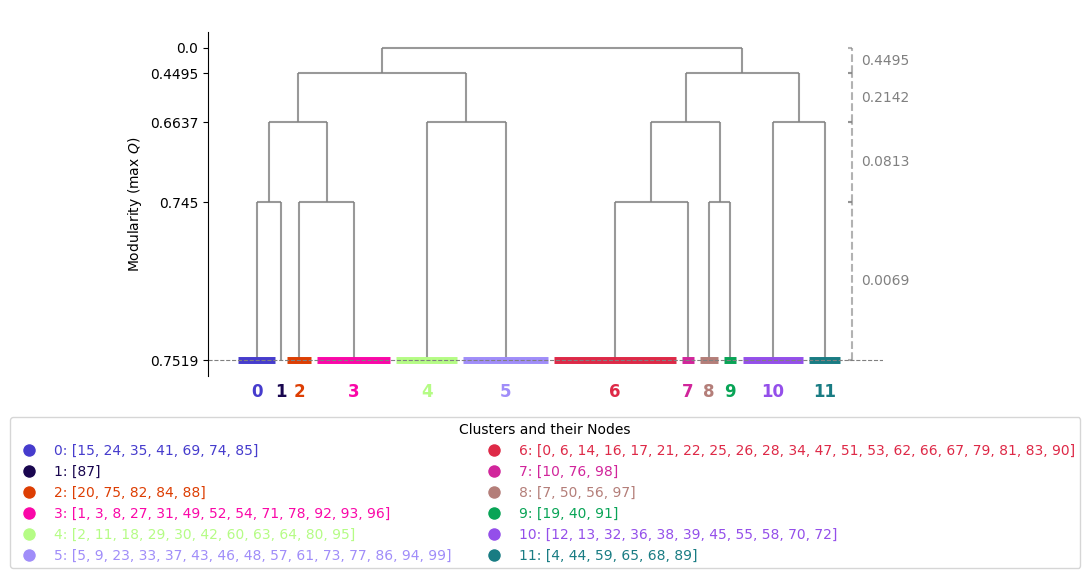

In [18]:
dendro = Dendrogram(G, communities=comms, division_modularities=div_mods, division_tree=div_tree)

dendro.draw(display_leafs=False, yaxis_abs_log=True, figsize=(10, 6))

In [19]:
division_tree = div_tree
communities = comms
division_modularities = div_mods


nodes = np.array(G.nodes)
leafs_clustering_ordering = [c for cluster in communities for c in cluster]
node_positions = {
    leaf: int(node) for node, leaf in zip(nodes, leafs_clustering_ordering)
}

In [20]:
# res = it_searcher.run_with_sampleset_info(num_runs=1, save_results=False)

In [21]:
# horizontal_coords = {}
# subclusters_arr = []

# for level in reversed(range(len(division_tree))):
#     level_clustering = division_tree[level]

#     # CASE OF FINAL CLUSTERING (LEAFS):
#     # For every cluster in the final clustering:
#     #   For every leaf in a cluster:
#     #       1. scatter it
#     #   2. then draw one horizontal line for visually agglomerating a cluster
#     if level == len(division_tree) - 1:
#         for cluster in level_clustering:
#             print(level, cluster)
#             cluster_leafs_positioned = [
#                 node_positions[node] for node in cluster
#             ]

#             base_modularity_zero = division_modularities[0]

#             # x (horizontal) corrds of the cluster - to know where to start and stop drawing
#             xmin = min(cluster_leafs_positioned)
#             xmax = max(cluster_leafs_positioned)
#             xmid = (xmin + xmax) / 2

#             # In the case of final clustering ymin is the ground/base of 0
#             ymin = base_modularity_zero
#             # ymax = Y_levels[level - 1]
#             # ax.vlines(
#             #     x=xmid,
#             #     ymin=ymin,
#             #     ymax=ymax,
#             #     colors=vline_color,
#             #     alpha=hier_line_alpha,
#             # )
#             # Mark x coord mids to know where to simplify plotting the next dendrogram hierarchy level
#             horizontal_coords[hash(tuple(cluster))] = xmid


#             # level_list = []
#             # if display_leafs:
#                 # 1.
#                 # for x in cluster_leafs_positioned:
#                     # ax.scatter(
#                     #     x,
#                     #     base_modularity_zero,
#                     #     color=cluster_colors[hash(tuple(cluster))],
#                     #     s=leafs_scatter_settings["s"],
#                     #     alpha=leafs_scatter_settings["alpha"],
#                     # )


#                 # 2.
#                 # ax.hlines(
#                 #     y=base_modularity_zero,
#                 #     xmin=xmin,
#                 #     xmax=xmax,
#                 #     colors=cluster_colors[hash(tuple(cluster))],
#                 #     alpha=leafs_hlines_settings["alpha"],
#                 #     linewidth=leafs_hlines_settings["linewidth"],
#                 # )

#             # else:
#             #     # 2.
#             #     ax.hlines(
#             #         y=base_modularity_zero,
#             #         xmin=xmin,
#             #         xmax=xmax,
#             #         colors=cluster_colors[hash(tuple(cluster))],
#             #         alpha=CLUSTER_HLINES["alpha"],
#             #         linewidth=CLUSTER_HLINES["linewidth"],
#             #     )

#     # CASE OF NON-FINAL DIVISION TREE LEVELS (CLADES):
#     else:
#         # In a currently considered hierarchy level of the division tree:
#         # A. For each cluster in the clustering of that level:
#         #   1. find subclusters of this cluster (the later division of that cluster),
#         #      called "subsequent clusters" below;
#         #      to know, where to start and end plotting lines (calculate positions);
#         #      paying attention to: the order of the clusters in each level of the division tree
#         #      shall not be taken for granted, hence we do a double "for" loop;
#         #   2. draw appropriate plot elements corresponding to this level of the division tree:
#         #      - vertical line connecting "subsequent" (check glossary below) divisions
#         #        with the current division;
#         #      - horizontal line (Y axis markers) correspondant to that level;

#         # B. IMPORTANT: Note that on each hierarchy level of the hierarchical search method
#         # a further division of a given cluster may or may not occur. (A community may
#         # or may not be further divided in later hierarchical search calls.)
#         #
#         # That's why a considered community may have:
#         #   1. only one subcluster ("simplicifolious") - itself
#         #      (in a case of no further divisions),
#         #   2. two subclusters (in the case of further binary division).
#         # The two cases are handled.

#         # GLOSSARY:
#         # "Subsequent" - meaning:
#         # one hierarchy level lower (deeper) in the division tree <=> ...
#         # ... <=> one hierarchy level higher in a reversed division tree
#         subsequent_clusters = division_tree[level + 1]
#         subclusters = {}

#         # A.1
#         for subsequent_cluster in subsequent_clusters:
#             for cluster in level_clustering:
#                 if set(subsequent_cluster).issubset(set(cluster)):
#                     key_clus = hash(tuple(cluster))
#                     if key_clus not in subclusters.keys():
#                         subclusters[key_clus] = subsequent_cluster
#                     else:
#                         subclusters[key_clus] = (
#                             subclusters.get(key_clus),
#                             subsequent_cluster,
#                         )
#         subclusters_arr.append(subclusters)
#         # A.2
#         for cluster in level_clustering:
#             # y = Y_levels[level]
#             key_clus = hash(tuple(cluster))

#             # CASE B.2:
#             # two subcommunities - tuple (of lists)
#             if type(subclusters[key_clus]) == tuple:
#                 c0, c1 = subclusters[key_clus]
#                 key1, key2 = hash(tuple(c0)), hash(tuple(c1))
#                 print(level)
#                 print(f"c0: {c0}, c1: {c1}")
#                 print()
#                 # Coords for plotting
#                 if (
#                     key1 in horizontal_coords.keys()
#                     and key2 in horizontal_coords.keys()
#                 ):
#                     mid_c0 = horizontal_coords[key1]
#                     mid_c1 = horizontal_coords[key2]
#                     mid = (mid_c0 + mid_c1) / 2
#                     horizontal_coords[hash(tuple(cluster))] = mid

#                     # Draw vertical line for this level
#                     # ymin = y
#                     # ymax = Y_levels[level - 1]
#                     # if level != 0:
#                     #     ax.vlines(
#                     #         x=mid,
#                     #         ymin=ymin,
#                     #         ymax=ymax,
#                     #         colors=vline_color,
#                     #         alpha=hier_line_alpha,
#                     #     )

#                 # Connect clusters with horizontal line
#                 # ax.hlines(
#                 #     y=y,
#                 #     xmin=mid_c0,
#                 #     xmax=mid_c1,
#                 #     colors=hline_color,
#                 #     alpha=hier_line_alpha,
#                 # )

#             # CASE B.1:
#             # only one subcommunity - list
#             elif type(subclusters[key_clus]) == list and level != 0:
#                 # Draw vertical line for this level
#                 mid_c0 = horizontal_coords[hash(tuple(cluster))]
#                 # ymin = y
#                 # ymax = Y_levels[level - 1]

#                 # ax.vlines(
#                 #     x=mid_c0,
#                 #     ymin=ymin,
#                 #     ymax=ymax,
#                 #     colors=vline_color,
#                 #     alpha=hier_line_alpha,
#                 # )
#                 pass
        

In [22]:
class Node:
    def __init__(self, id, values, left=None, right=None, parent=None):
        self.id = id
        self.values = values
        self.left = left
        self.right = right
        self.parent = parent

    def __str__(self):
        return f"Node(id={self.id}, values={self.values})"
    
    def __repr__(self):
        return f"Node(values={self.values}, left={self.left}, right={self.right})"
    
    def __eq__(self, node):
        if not isinstance(node, Node):
            return False
        return self.id == node.id and sorted(self.values) == sorted(node.values)

class Tree:
    def __init__(self, root):
        self.root = root
        self.nodes = [root]

In [23]:
division_tree = div_tree

In [33]:
root = Node(id=hash(tuple(G.nodes)), values=list(G.nodes), left=None, right=None, parent=None)

nodes = {}
# nodes[root.id] = root

for level in reversed(range(len(division_tree))):
    level_clustering = division_tree[level]

    # CASE OF FINAL CLUSTERING (LEAFS):
    # For every cluster in the final clustering:
    #   For every leaf in a cluster:
    #       1. scatter it
    #   2. then draw one horizontal line for visually agglomerating a cluster
    if level == len(division_tree) - 1:
        for cluster in level_clustering:
            print(level, cluster)
            leaf_node = Node(id=hash(tuple(cluster)), values=cluster, left=None, right=None, parent=None)
            nodes[leaf_node.id] = leaf_node


    # CASE OF NON-FINAL DIVISION TREE LEVELS (CLADES):
    else:
        # In a currently considered hierarchy level of the division tree:
        # A. For each cluster in the clustering of that level:
        #   1. find subclusters of this cluster (the later division of that cluster),
        #      called "subsequent clusters" below;
        #      to know, where to start and end plotting lines (calculate positions);
        #      paying attention to: the order of the clusters in each level of the division tree
        #      shall not be taken for granted, hence we do a double "for" loop;
        #   2. draw appropriate plot elements corresponding to this level of the division tree:
        #      - vertical line connecting "subsequent" (check glossary below) divisions
        #        with the current division;
        #      - horizontal line (Y axis markers) correspondant to that level;

        # B. IMPORTANT: Note that on each hierarchy level of the hierarchical search method
        # a further division of a given cluster may or may not occur. (A community may
        # or may not be further divided in later hierarchical search calls.)
        #
        # That's why a considered community may have:
        #   1. only one subcluster ("simplicifolious") - itself
        #      (in a case of no further divisions),
        #   2. two subclusters (in the case of further binary division).
        # The two cases are handled.

        # GLOSSARY:
        # "Subsequent" - meaning:
        # one hierarchy level lower (deeper) in the division tree <=> ...
        # ... <=> one hierarchy level higher in a reversed division tree
        subsequent_clusters = division_tree[level + 1]
        subclusters = {}

        # A.1
        for subsequent_cluster in subsequent_clusters: # children clusters
            for cluster in level_clustering: # parent clusters
                if set(subsequent_cluster).issubset(set(cluster)): # if subsequent cluster is child of the parent
                    # print()
                    # print(subsequent_cluster, "is subset of", cluster)
                    key_clus = hash(tuple(cluster))

                    # Child                   
                    # key_subclus = hash(tuple(subsequent_cluster))
                    # node_subclus = nodes.get(key_subclus)
                    # Create the kid
                    # if node_subclus is None:
                    #     print("Error, there must be some leaves")
                    #     node_subclus = Node(id=key_subclus, values=subsequent_cluster, left=None, right=None, parent=parent_node)
                    #     nodes[node_subclus.id] = node_subclus

                    # node_subclus.parent = parent_node
                    
                    # Update info
                    if key_clus not in subclusters.keys():
                        subclusters[key_clus] = subsequent_cluster
                    else:
                        subclusters[key_clus] = (
                            subclusters.get(key_clus),
                            subsequent_cluster,
                        )                    

                    # The parent needs to be created
                    # parent_node = nodes.get(key_clus)
                    # if parent_node is None:
                    #     parent_node = Node(id=key_clus, values=cluster, left=None, right=None, parent=None)
                    #     nodes[parent_node.id] = parent_node
        # subclusters_arr.append(subclusters)
        # A.2
        for cluster in level_clustering:
            # y = Y_levels[level]
            key_clus = hash(tuple(cluster))

            # parent_node = nodes.get(key_clus)
            # if parent_node is None:
            #     print("Error")
            #     parent_node = Node(id=key_clus, values=cluster, left=None, right=None, parent=None)
            #     nodes[parent_node.id] = parent_node
            
            # CASE B.2:
            # two subcommunities - tuple (of lists)
            if type(subclusters[key_clus]) == tuple:
                c0, c1 = subclusters[key_clus]
                key1, key2 = hash(tuple(c0)), hash(tuple(c1))
                print(level)
                print(f"c0: {c0}, c1: {c1}")
                print()

                child_node_1 = nodes[key1]
                child_node_2 = nodes[key2]

                parent_node = Node(id=key_clus, values=cluster, left=child_node_1, right=child_node_2, parent=None)
                nodes[parent_node.id] = parent_node

                child_node_1.parent = parent_node
                child_node_2.parent = parent_node

                print(f"Child_1: {child_node_1},\n Parent_1: {child_node_1.parent}")
                print(f"Child_2: {child_node_2},\n Parent_2: {child_node_2.parent}")
                # print(child_node_1.parent)
                # print(child_node_2.parent)
                
                assert child_node_1.parent == parent_node
                assert child_node_2.parent == parent_node

                # print(cluster)
                # parent_node = nodes[key_clus]
                # parent_node.left = key1
                # parent_node.right = key2
                # parent_node.left = child_node_1
                # parent_node.right = child_node_2


            # CASE B.1:
            # only one subcommunity - list
            elif type(subclusters[key_clus]) == list and level != 0:
                pass
                # mid_c0 = horizontal_coords[hash(tuple(cluster))]
                # node = nodes[key_clus]
                # print("\nHere\n\n", node)
                # c = subclusters[key_clus]
                # key = hash(tuple(c))



root = nodes[root.id]
# del nodes        

4 [15, 24, 35, 41, 69, 74, 85]
4 [87]
4 [20, 75, 82, 84, 88]
4 [1, 3, 8, 27, 31, 49, 52, 54, 71, 78, 92, 93, 96]
4 [2, 11, 18, 29, 30, 42, 60, 63, 64, 80, 95]
4 [5, 9, 23, 33, 37, 43, 46, 48, 57, 61, 73, 77, 86, 94, 99]
4 [0, 6, 14, 16, 17, 21, 22, 25, 26, 28, 34, 47, 51, 53, 62, 66, 67, 79, 81, 83, 90]
4 [10, 76, 98]
4 [7, 50, 56, 97]
4 [19, 40, 91]
4 [12, 13, 32, 36, 38, 39, 45, 55, 58, 70, 72]
4 [4, 44, 59, 65, 68, 89]
3
c0: [15, 24, 35, 41, 69, 74, 85], c1: [87]

Child_1: Node(id=4692471290525986920, values=[15, 24, 35, 41, 69, 74, 85]),
 Parent_1: Node(id=9088353502645287822, values=[15, 24, 35, 41, 69, 74, 85, 87])
Child_2: Node(id=6325807715028088596, values=[87]),
 Parent_2: Node(id=9088353502645287822, values=[15, 24, 35, 41, 69, 74, 85, 87])
3
c0: [20, 75, 82, 84, 88], c1: [1, 3, 8, 27, 31, 49, 52, 54, 71, 78, 92, 93, 96]

Child_1: Node(id=-4780655504487882111, values=[20, 75, 82, 84, 88]),
 Parent_1: Node(id=8567147146463020880, values=[1, 3, 8, 20, 27, 31, 49, 52, 54, 71, 7

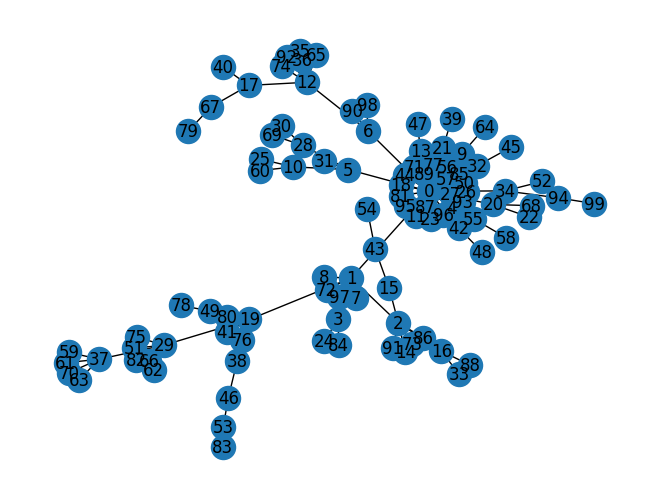

In [25]:
nx.draw(G, pos=nx.spring_layout(G), with_labels=True)

In [26]:
# plot_tree(root)

In [34]:
import networkx as nx
import matplotlib.pyplot as plt

def build_graph(G, node, level=0):
    """Recursively traverse the binary tree and add edges."""
    if node is None:
        return

    # Add node with label
    # label = f"{node.id}\n{node.values[:5]}{'...' if len(node.values) > 5 else ''}"
    def divide_label(values, len_per_line=6) -> str:
        lines = []
        for i in range(0, len(values), len_per_line):
            line = values[i:i+len_per_line]
            lines.append(", ".join(map(str, line)))
        return "\n".join(lines)
    
    label = divide_label(node.values)
    # mod_value = f"{div_mods[level]:.2f}"
    mod_value = div_mods[level]
    color = "red" if level == len(div_mods) - 1 else "blue"
    values = node.values

    G.add_node(node.id, label=label, mod_value=mod_value, color=color, values=values)

    # Add edges to children
    if node.left:
        G.add_edge(node.id, node.left.id)
        build_graph(G, node.left, level=level+1)

    if node.right:
        G.add_edge(node.id, node.right.id)
        build_graph(G, node.right, level=level+1)

def plot_tree(root):
    """Create and visualize the binary tree graph."""
    G = nx.DiGraph()
    build_graph(G, root)

    # Use Graphviz for a hierarchical layout (requires `graphviz` installed)
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

    # Extract node labels
    labels = nx.get_node_attributes(G, 'label')

    plt.figure(figsize=(14, 8))

    leaves = [n for n in G.nodes() if G.out_degree(n) == 0]
    internals = [n for n in G.nodes() if G.out_degree(n) > 0]

    # Draw internal nodes first
    nx.draw_networkx_nodes(G, pos,
                           nodelist=internals,
                           node_color="#cbdeee",
                           node_size=2800,)
                        #    edgecolors="black")
    # Draw leaf nodes (red)
    nx.draw_networkx_nodes(G, pos,
                           nodelist=leaves,
                           node_color="#5b98ca",
                           node_size=2800,)
                        #    edgecolors="black")

    # Draw edges
    nx.draw_networkx_edges(G, pos, arrows=False)

    # Draw labels: white+bold for leaves, black normal for internals
    for node, (x, y) in pos.items():
        label = labels[node]
        node_data = G.nodes[node]
        mod_value = node_data['mod_value']
        mod_color = node_data['color']
        values = node_data['values']

        label = str(len(values))

        if node in leaves:
            plt.text(x, y, label + "\n" + f"{mod_value:.2f}",
                     ha="center", va="center",
                     fontsize=7, color=mod_color, fontweight="bold", wrap=True)
        else:
            plt.text(x, y, label + "\n\n" + f"{mod_value:.2f}",
                     ha="center", va="center",
                     fontsize=7, color=mod_color, fontweight="normal", wrap=True)

    plt.title("Division Tree", fontsize=14)
    plt.show()

# Example: assuming your 'root' node is already built
# plot_tree(root)

In [108]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def build_graph(G, node, level=0):
    """Recursively traverse the binary tree and add edges."""
    if node is None:
        return

    def divide_label(values, len_per_line=6) -> str:
        lines = []
        for i in range(0, len(values), len_per_line):
            line = values[i:i+len_per_line]
            lines.append(", ".join(map(str, line)))
        return "\n".join(lines)

    label = divide_label(node.values)
    mod_value = div_mods[level]
    color = "#4c72b0" if node.left or node.right else "#d35d6e"  # blue for internal, red for leaves
    values = node.values

    G.add_node(node.id, label=label, mod_value=mod_value, color=color, values=values, level=level)

    if node.left:
        G.add_edge(node.id, node.left.id)
        build_graph(G, node.left, level + 1)
    if node.right:
        G.add_edge(node.id, node.right.id)
        build_graph(G, node.right, level + 1)


def plot_tree(root):
    """Create and visualize the binary tree graph with a modern aesthetic."""
    G = nx.DiGraph()
    build_graph(G, root)
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

    # Node classification
    leaves = [n for n in G.nodes() if G.out_degree(n) == 0]
    internals = [n for n in G.nodes() if G.out_degree(n) > 0]
    labels = nx.get_node_attributes(G, 'label')

    # Modern color scheme
    internal_color = "#b8d3e9"
    leaf_color = "#f2a7a7"

    plt.figure(figsize=(14, 8))
    plt.style.use("seaborn-v0_8-white")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos,
                           nodelist=internals,
                           node_color=internal_color,
                           node_size=2800,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    nx.draw_networkx_nodes(G, pos,
                           nodelist=leaves,
                           node_color=leaf_color,
                           node_size=2800,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    # Draw edges — subtle and transparent
    nx.draw_networkx_edges(G, pos,
                           arrows=False,
                           edge_color="#7d8ca3",
                           width=1.0,
                           alpha=0.6)

    # Draw labels with clean, modern typography
    for node, (x, y) in pos.items():
        node_data = G.nodes[node]
        mod_value = node_data['mod_value']
        color = node_data['color']
        values = node_data['values']

        # label = f"{len(values)}\n{mod_value:.2f}"
        text_color = "white" if node in leaves else "#1e2a36"
        font_weight = "bold" if node in leaves else "semibold"
        # label1 = str(len(values))
        # label2 = f"{mod_value:.2f}"
        label1 = f"Pr.size: {len(values)}"
        label2 = f"Ch.str.: {14333}"
        label = label1 + "\n" + label2

        # plt.text(x, y,
        #          label1,
        #          ha="center", va="center",
        #         #  ha="center",
        #          fontsize=9,
        #          color=text_color,
        #          fontweight=font_weight,
        #          wrap=True,
        #          bbox=dict(facecolor=color,
        #                    boxstyle="round,pad=0.4",
        #                    edgecolor="#e6e6e6",
        #                    lw=0.8,
        #                    alpha=0.85)
        # )
        # plt.text(x, y-30,
        #          label2,
        #          ha="center", va="center",
        #          fontsize=9,
        #          color=text_color,
        #          fontweight=font_weight,
        #          wrap=True,
        #          bbox=dict(facecolor=color,
        #                    boxstyle="round,pad=0.4",
        #                    edgecolor="#e6e6e6",
        #                    lw=0.8,
        #                    alpha=0.85)
        # )
        plt.text(x, y,
                 label,
                 ha="center", va="center",
                #  ha="center",
                 fontsize=9,
                 color=text_color,
                 fontweight=font_weight,
                 wrap=True,
                 bbox=dict(facecolor=color,
                           boxstyle="round,pad=0.4",
                           edgecolor="#e6e6e6",
                           lw=0.8,
                           alpha=0.85)
        )

    levels = sorted(set(nx.get_node_attributes(G, 'level').values()))
    modularities = [div_mods[l] for l in levels]

    # Annotate modularity per level at the right of the plot
    xmax = max(x for x, y in pos.values())
    pos_values_sorted = sorted(pos.values(), key=lambda x: (x[1], x[0]))
    last_1, last_2 = pos_values_sorted[-1], pos_values_sorted[-2]
    dx = abs(last_2[0] - last_1[0])
    for lvl, m in zip(levels, modularities):
        # Find nodes at this level
        nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl]
        if nodes_at_level:
            # Use mean X position of nodes at this level for placement
            plt.text(xmax + dx, np.mean([pos[n][1] for n in nodes_at_level]), f"{m:.4f}",
                     ha="left", va="center", fontsize=9, color="#444444", fontweight="semibold")
            
            plt.hlines(y=np.mean([pos[n][1] for n in nodes_at_level]),
                      xmin=(xmax+dx) - (xmax+dx/2), xmax=xmax+dx,
                      colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6)
            
    legend_elements = [
        Patch(facecolor=internal_color, edgecolor="#2b3a42", label="Internal nodes"),
        Patch(facecolor=leaf_color, edgecolor="#2b3a42", label="Leaf nodes"),
    ]

    plt.legend(handles=legend_elements,
            # loc="upper left",   # or "lower right" depending on your layout
            frameon=False,
            fontsize=10)

    plt.title("Chain strength & problem size in the hierarchical division tree", fontsize=16, fontweight="bold", color="#2b3a42", pad=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


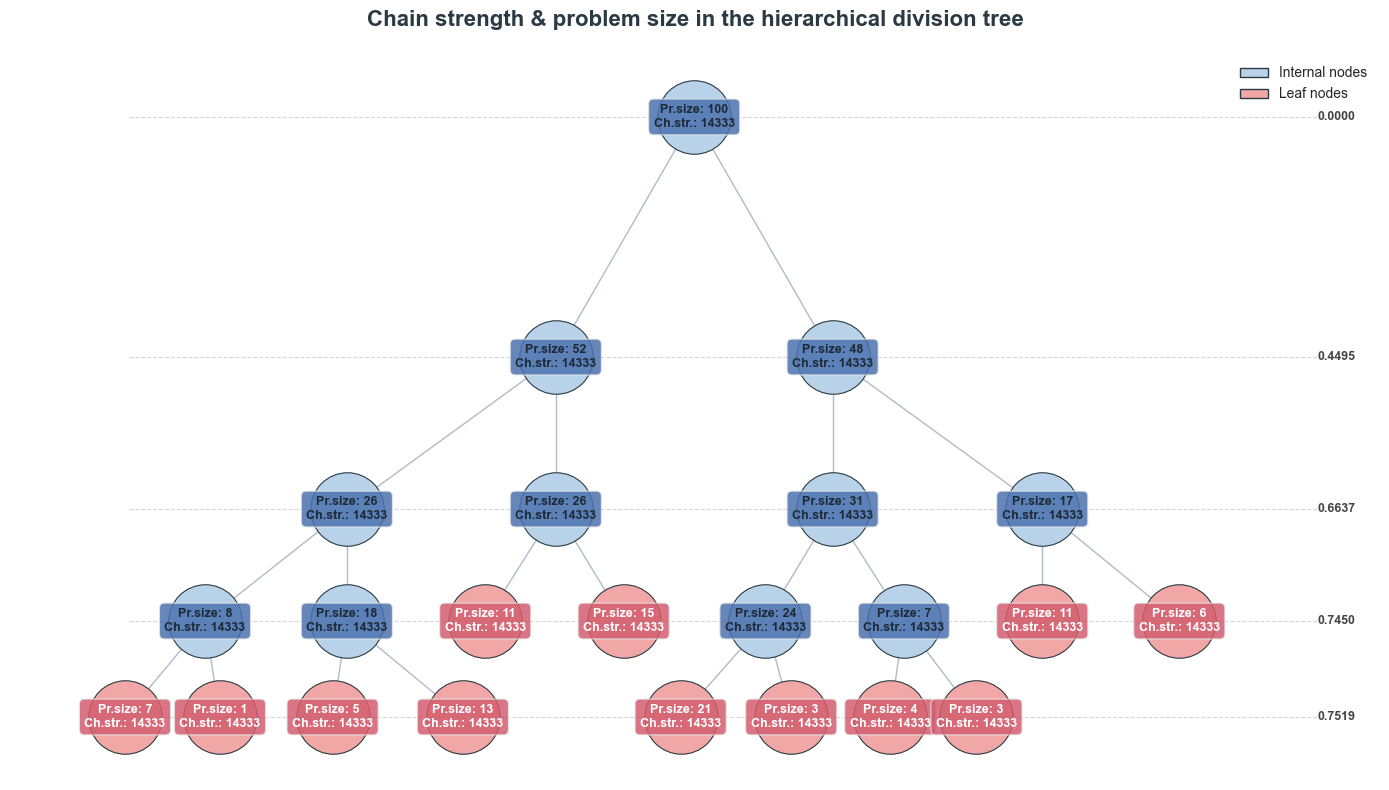

In [109]:
plot_tree(root)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def build_graph(G, node, level=0):
    """Recursively traverse the binary tree and add edges."""
    if node is None:
        return

    def divide_label(values, len_per_line=6) -> str:
        lines = []
        for i in range(0, len(values), len_per_line):
            line = values[i:i+len_per_line]
            lines.append(", ".join(map(str, line)))
        return "\n".join(lines)

    label = divide_label(node.values)
    mod_value = div_mods[level]
    color = "#4c72b0" if node.left or node.right else "#d35d6e"  # blue for internal, red for leaves
    values = node.values

    G.add_node(node.id, label=label, mod_value=mod_value, color=color, values=values, level=level)

    if node.left:
        G.add_edge(node.id, node.left.id)
        build_graph(G, node.left, level + 1)
    if node.right:
        G.add_edge(node.id, node.right.id)
        build_graph(G, node.right, level + 1)


def plot_tree(root):
    """Create and visualize the binary tree graph with a modern aesthetic."""
    G = nx.DiGraph()
    build_graph(G, root)
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

    # Node classification
    leaves = [n for n in G.nodes() if G.out_degree(n) == 0]
    internals = [n for n in G.nodes() if G.out_degree(n) > 0]
    labels = nx.get_node_attributes(G, 'label')

    # Modern color scheme
    internal_color = "#b8d3e9"
    leaf_color = "#f2a7a7"

    plt.figure(figsize=(14, 8))
    plt.style.use("seaborn-v0_8-white")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos,
                           nodelist=internals,
                           node_color=internal_color,
                           node_size=2800,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    nx.draw_networkx_nodes(G, pos,
                           nodelist=leaves,
                           node_color=leaf_color,
                           node_size=2800,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    # Draw edges — subtle and transparent
    nx.draw_networkx_edges(G, pos,
                           arrows=False,
                           edge_color="#7d8ca3",
                           width=1.0,
                           alpha=0.6)

    # Draw labels with clean, modern typography
    for node, (x, y) in pos.items():
        node_data = G.nodes[node]
        mod_value = node_data['mod_value']
        color = node_data['color']
        values = node_data['values']

        # label = f"{len(values)}\n{mod_value:.2f}"
        text_color = "white" if node in leaves else "#1e2a36"
        font_weight = "bold" if node in leaves else "semibold"
        # label1 = str(len(values))
        # label2 = f"{mod_value:.2f}"
        label1 = f"Pr.size: {len(values)}"
        label2 = f"Ch.str.: {14333}"
        label = label1 + "\n" + label2

        # plt.text(x, y,
        #          label1,
        #          ha="center", va="center",
        #         #  ha="center",
        #          fontsize=9,
        #          color=text_color,
        #          fontweight=font_weight,
        #          wrap=True,
        #          bbox=dict(facecolor=color,
        #                    boxstyle="round,pad=0.4",
        #                    edgecolor="#e6e6e6",
        #                    lw=0.8,
        #                    alpha=0.85)
        # )
        # plt.text(x, y-30,
        #          label2,
        #          ha="center", va="center",
        #          fontsize=9,
        #          color=text_color,
        #          fontweight=font_weight,
        #          wrap=True,
        #          bbox=dict(facecolor=color,
        #                    boxstyle="round,pad=0.4",
        #                    edgecolor="#e6e6e6",
        #                    lw=0.8,
        #                    alpha=0.85)
        # )
        plt.text(x, y,
                 label,
                 ha="center", va="center",
                #  ha="center",
                 fontsize=9,
                 color=text_color,
                 fontweight=font_weight,
                 wrap=True,
                 bbox=dict(facecolor=color,
                           boxstyle="round,pad=0.4",
                           edgecolor="#e6e6e6",
                           lw=0.8,
                           alpha=0.85)
        )

    levels = sorted(set(nx.get_node_attributes(G, 'level').values()))
    modularities = [div_mods[l] for l in levels]

    # Annotate modularity per level at the right of the plot
    xmax = max(x for x, y in pos.values())
    pos_values_sorted = sorted(pos.values(), key=lambda x: (x[1], x[0]))
    last_1, last_2 = pos_values_sorted[-1], pos_values_sorted[-2]
    dx = abs(last_2[0] - last_1[0])
    for lvl, m in zip(levels, modularities):
        # Find nodes at this level
        nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl]
        if nodes_at_level:
            # Use mean X position of nodes at this level for placement
            plt.text(xmax + dx, np.mean([pos[n][1] for n in nodes_at_level]), f"{m:.4f}",
                     ha="left", va="center", fontsize=9, color="#444444", fontweight="semibold")
            
            plt.hlines(y=np.mean([pos[n][1] for n in nodes_at_level]),
                      xmin=(xmax+dx) - (xmax+dx/2), xmax=xmax+dx,
                      colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6)
            
    legend_elements = [
        Patch(facecolor=internal_color, edgecolor="#2b3a42", label="Internal nodes"),
        Patch(facecolor=leaf_color, edgecolor="#2b3a42", label="Leaf nodes"),
    ]

    plt.legend(handles=legend_elements,
            # loc="upper left",   # or "lower right" depending on your layout
            frameon=False,
            fontsize=10)

    plt.title("Chain strength & problem size in the hierarchical division tree", fontsize=16, fontweight="bold", color="#2b3a42", pad=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [99]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_tree_with_modularity_axis(root):
    """Original modern tree layout with modularity axis annotations."""
    G = nx.DiGraph()
    build_graph(G, root)  # your existing build_graph function
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

    leaves = [n for n in G.nodes() if G.out_degree(n) == 0]
    internals = [n for n in G.nodes() if G.out_degree(n) > 0]
    labels = nx.get_node_attributes(G, 'label')

    def divide_label(values, len_per_line=6) -> str:
        lines = []
        for i in range(0, len(values), len_per_line):
            line = values[i:i+len_per_line]
            lines.append(", ".join(map(str, line)))
        return "\n".join(lines)

    fig, ax = plt.subplots(figsize=(14, 8))
    plt.style.use("seaborn-v0_8-white")

    # Node colors
    internal_color = "#b8d3e9"
    leaf_color = "#f2a7a7"

    node_size = 2800

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, nodelist=internals, node_color=internal_color,
                           node_size=node_size, edgecolors="#2b3a42", linewidths=0.8, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=leaves, node_color=leaf_color,
                           node_size=node_size, edgecolors="#2b3a42", linewidths=0.8, ax=ax)

    # Draw edges
    nx.draw_networkx_edges(G, pos, arrows=False, edge_color="#7d8ca3", width=1.0, alpha=0.6, ax=ax)

    # Draw node labels
    for node, (x, y) in pos.items():
        data = G.nodes[node]
        # mod_value = data['mod_value']
        values = data['values']
        text_color = "black" if node in leaves else "#1e2a36"
        font_weight = "bold" if node in leaves else "semibold"
        # label = f"{len(values)}"
        lvl = data["level"]
        nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl]
        n_nodes = len(nodes_at_level)
        if n_nodes in [1]:
            max_items_per_line = len(values) // 2
        elif n_nodes in [2]:
            max_items_per_line = 10
        else:
            max_items_per_line = 4

        label = divide_label(values, max_items_per_line)
        label = "[" + label + "]"     

        # plt.text(x, y, label,
        #          ha="center", va="center",
        #          fontsize=9, color=text_color, fontweight=font_weight,
        #          wrap=True, zorder=4)
        plt.text(x, y, label,
                 ha="center", va="center",
                 fontsize=9, color=text_color, fontweight=font_weight,
                 wrap=True, zorder=4)

    # --- Add modularity axis on the right ---
    # Get all unique levels and modularities
    levels = sorted(set(nx.get_node_attributes(G, 'level').values()))
    modularities = [div_mods[l] for l in levels]

    # Annotate modularity per level at the right of the plot
    xmax = max(x for x, y in pos.values())
    pos_values_sorted = sorted(pos.values(), key=lambda x: (x[1], x[0]))
    last_1, last_2 = pos_values_sorted[-1], pos_values_sorted[-2]
    dx = abs(last_2[0] - last_1[0])
    for lvl, m in zip(levels, modularities):
        # Find nodes at this level
        nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl]
        if nodes_at_level:
            # Use mean X position of nodes at this level for placement
            mean_x = sum(pos[n][0] for n in nodes_at_level) / len(nodes_at_level)
            ax.text(xmax + dx, np.mean([pos[n][1] for n in nodes_at_level]), f"{m:.4f}",
                     ha="left", va="center", fontsize=9, color="#444444", fontweight="semibold")
            
            ax.hlines(y=np.mean([pos[n][1] for n in nodes_at_level]),
                      xmin=(xmax+dx) - (xmax+dx/2), xmax=xmax+dx,
                      colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6)
    
    y_coords_end = max(pos[n][1] for n in nodes_at_level)
    nodes_at_0 = [n for n, d in G.nodes(data=True) if d['level'] == 0]
    y_coords_start = min([pos[n][1] for n in nodes_at_0])
    # ax.vlines(x=xmax+dx / 2, ymin=y_coords_start, ymax=y_coords_end,  # extend slightly above/below
    #           colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6)

    ax.set_title("Hierarchcial Division Tree", fontsize=16, fontweight="bold", color="#2b3a42", pad=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


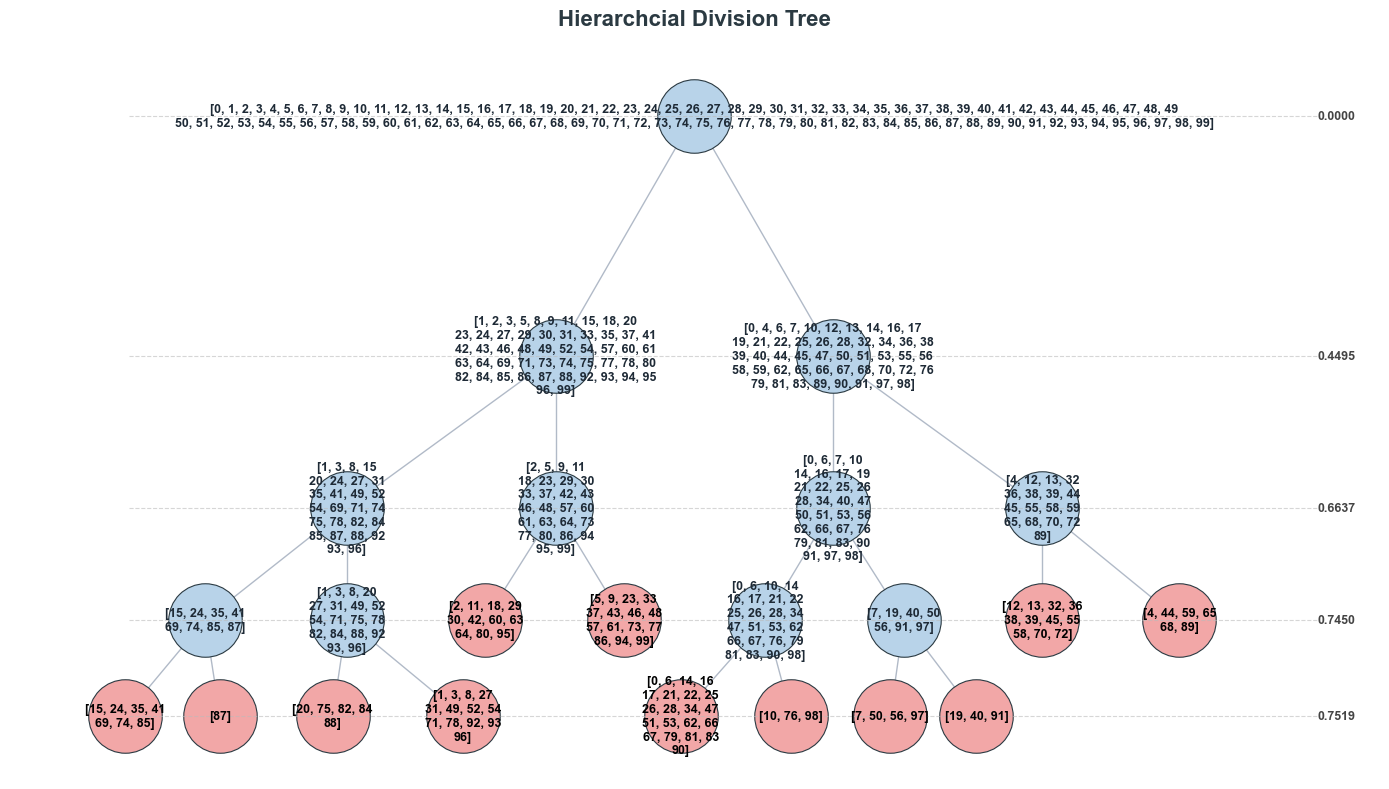

In [100]:
plot_tree_with_modularity_axis(root)

In [240]:
def plot_tree_dark(root):
    G = nx.DiGraph()
    build_graph(G, root)
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

    plt.figure(figsize=(14, 8), facecolor="#0f1419")
    plt.axis("off")

    leaves = [n for n in G.nodes() if G.out_degree(n) == 0]
    internals = [n for n in G.nodes() if G.out_degree(n) > 0]

    # Draw edges (soft neon glow)
    nx.draw_networkx_edges(G, pos,
                           arrows=False,
                           edge_color="#24c2cb",
                           width=1.2,
                           alpha=0.4)

    # Internal nodes: cool cyan
    nx.draw_networkx_nodes(G, pos, nodelist=internals,
                           node_color="#253745",
                           node_size=2500,
                           edgecolors="#24c2cb",
                           linewidths=1.2)

    # Leaf nodes: hot magenta
    nx.draw_networkx_nodes(G, pos, nodelist=leaves,
                           node_color="#b83280",
                           node_size=2500,
                           edgecolors="#ff76c7",
                           linewidths=1.2)

    # Labels (white for visibility)
    for node, (x, y) in pos.items():
        plt.text(x, y,
                 f"{len(G.nodes[node]['values'])}\n{G.nodes[node]['mod_value']:.2f}",
                 ha="center", va="center",
                 fontsize=9, color="white",
                 fontweight="bold" if node in leaves else "normal")

    plt.title("Binary Tree (Dark Neon)", fontsize=16, color="#24c2cb", fontweight="bold", pad=20)
    plt.show()


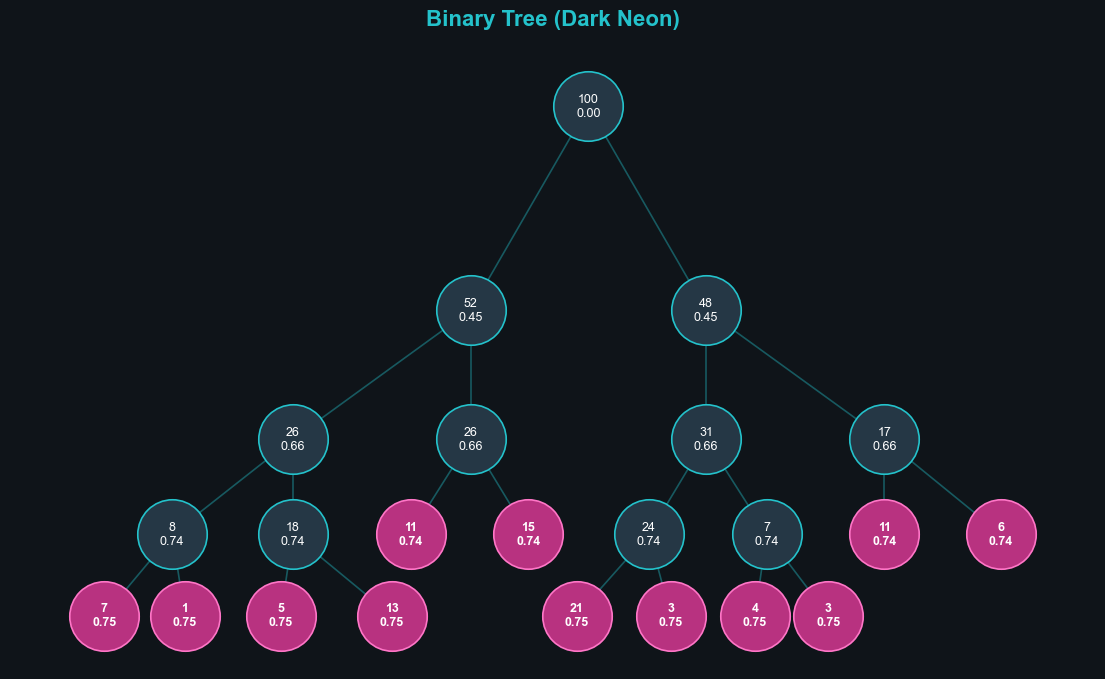

In [242]:
plot_tree_dark(root)

In [102]:
nodes[root.id]

Node(values=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99], left=Node(id=-4488037458791990694, values=[1, 2, 3, 5, 8, 9, 11, 15, 18, 20, 23, 24, 27, 29, 30, 31, 33, 35, 37, 41, 42, 43, 46, 48, 49, 52, 54, 57, 60, 61, 63, 64, 69, 71, 73, 74, 75, 77, 78, 80, 82, 84, 85, 86, 87, 88, 92, 93, 94, 95, 96, 99]), right=Node(id=-4482907170547344373, values=[0, 4, 6, 7, 10, 12, 13, 14, 16, 17, 19, 21, 22, 25, 26, 28, 32, 34, 36, 38, 39, 40, 44, 45, 47, 50, 51, 53, 55, 56, 58, 59, 62, 65, 66, 67, 68, 70, 72, 76, 79, 81, 83, 89, 90, 91, 97, 98]))

In [103]:
print_tree(root)

 Node(id=4479737025582696436, values=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])
	 Node(id=-4488037458791990694, values=[1, 2, 3, 5, 8, 9, 11, 15, 18, 20, 23, 24, 27, 29, 30, 31, 33, 35, 37, 41, 42, 43, 46, 48, 49, 52, 54, 57, 60, 61, 63, 64, 69, 71, 73, 74, 75, 77, 78, 80, 82, 84, 85, 86, 87, 88, 92, 93, 94, 95, 96, 99])
		 Node(id=-1845227881356807096, values=[1, 3, 8, 15, 20, 24, 27, 31, 35, 41, 49, 52, 54, 69, 71, 74, 75, 78, 82, 84, 85, 87, 88, 92, 93, 96])
			 Node(id=9088353502645287822, values=[15, 24, 35, 41, 69, 74, 85, 87])
				 Node(id=4692471290525986920, values=[15, 24, 35, 41, 69, 74, 85])
				 Node(id=6325807715028088596, values

In [105]:
len(nodes)

23

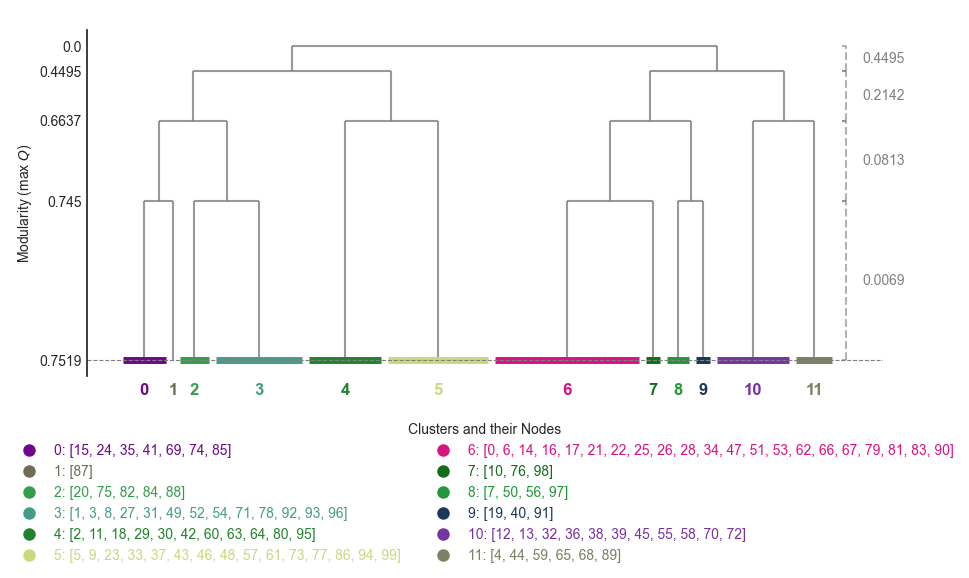

In [296]:
dendro.draw(display_leafs=False, yaxis_abs_log=True, figsize=(10, 6))

In [195]:
first_div = div_tree[1]
c0, c1 = first_div[0], first_div[1]

In [ ]:
sample_like = np.array[]

[1,
 2,
 3,
 5,
 8,
 9,
 11,
 15,
 18,
 20,
 23,
 24,
 27,
 29,
 30,
 31,
 33,
 35,
 37,
 41,
 42,
 43,
 46,
 48,
 49,
 52,
 54,
 57,
 60,
 61,
 63,
 64,
 69,
 71,
 73,
 74,
 75,
 77,
 78,
 80,
 82,
 84,
 85,
 86,
 87,
 88,
 92,
 93,
 94,
 95,
 96,
 99]

In [172]:
root

Node(values=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99], left=Node(id=-4488037458791990694, values=[1, 2, 3, 5, 8, 9, 11, 15, 18, 20, 23, 24, 27, 29, 30, 31, 33, 35, 37, 41, 42, 43, 46, 48, 49, 52, 54, 57, 60, 61, 63, 64, 69, 71, 73, 74, 75, 77, 78, 80, 82, 84, 85, 86, 87, 88, 92, 93, 94, 95, 96, 99]), right=Node(id=-4482907170547344373, values=[0, 4, 6, 7, 10, 12, 13, 14, 16, 17, 19, 21, 22, 25, 26, 28, 32, 34, 36, 38, 39, 40, 44, 45, 47, 50, 51, 53, 55, 56, 58, 59, 62, 65, 66, 67, 68, 70, 72, 76, 79, 81, 83, 89, 90, 91, 97, 98]))

In [91]:
def print_tree(root, level=0):
    print("\t" * level, root)
    if root.left:
        print_tree(root.left, level + 1)
    if root.right:
        print_tree(root.right, level + 1)

In [92]:
print_tree(nodes[root.id])

 Node(id=4479737025582696436, values=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])
	 Node(id=-4488037458791990694, values=[1, 2, 3, 5, 8, 9, 11, 15, 18, 20, 23, 24, 27, 29, 30, 31, 33, 35, 37, 41, 42, 43, 46, 48, 49, 52, 54, 57, 60, 61, 63, 64, 69, 71, 73, 74, 75, 77, 78, 80, 82, 84, 85, 86, 87, 88, 92, 93, 94, 95, 96, 99])
		 Node(id=-1845227881356807096, values=[1, 3, 8, 15, 20, 24, 27, 31, 35, 41, 49, 52, 54, 69, 71, 74, 75, 78, 82, 84, 85, 87, 88, 92, 93, 96])
			 Node(id=9088353502645287822, values=[15, 24, 35, 41, 69, 74, 85, 87])
				 Node(id=4692471290525986920, values=[15, 24, 35, 41, 69, 74, 85])
				 Node(id=6325807715028088596, values

In [148]:
nodes[root.id]
nodes[root.id]

In [ ]:
root.left

AttributeError: 'int' object has no attribute 'parent'

In [137]:
root.right

-4482907170547344373

In [82]:
subclusters_arr

[{9088353502645287822: ([15, 24, 35, 41, 69, 74, 85], [87]),
  8567147146463020880: ([20, 75, 82, 84, 88],
   [1, 3, 8, 27, 31, 49, 52, 54, 71, 78, 92, 93, 96]),
  4596517741008876966: [2, 11, 18, 29, 30, 42, 60, 63, 64, 80, 95],
  4987929133815797303: [5,
   9,
   23,
   33,
   37,
   43,
   46,
   48,
   57,
   61,
   73,
   77,
   86,
   94,
   99],
  4676066414742340692: ([0,
    6,
    14,
    16,
    17,
    21,
    22,
    25,
    26,
    28,
    34,
    47,
    51,
    53,
    62,
    66,
    67,
    79,
    81,
    83,
    90],
   [10, 76, 98]),
  8779294723002937148: ([7, 50, 56, 97], [19, 40, 91]),
  6147776293180325152: [12, 13, 32, 36, 38, 39, 45, 55, 58, 70, 72],
  7486312350342834528: [4, 44, 59, 65, 68, 89]},
 {-1845227881356807096: ([15, 24, 35, 41, 69, 74, 85, 87],
   [1, 3, 8, 20, 27, 31, 49, 52, 54, 71, 75, 78, 82, 84, 88, 92, 93, 96]),
  2961199247638308705: ([2, 11, 18, 29, 30, 42, 60, 63, 64, 80, 95],
   [5, 9, 23, 33, 37, 43, 46, 48, 57, 61, 73, 77, 86, 94, 99])

In [84]:
for d in subclusters_arr:
    print(d)

{9088353502645287822: ([15, 24, 35, 41, 69, 74, 85], [87]), 8567147146463020880: ([20, 75, 82, 84, 88], [1, 3, 8, 27, 31, 49, 52, 54, 71, 78, 92, 93, 96]), 4596517741008876966: [2, 11, 18, 29, 30, 42, 60, 63, 64, 80, 95], 4987929133815797303: [5, 9, 23, 33, 37, 43, 46, 48, 57, 61, 73, 77, 86, 94, 99], 4676066414742340692: ([0, 6, 14, 16, 17, 21, 22, 25, 26, 28, 34, 47, 51, 53, 62, 66, 67, 79, 81, 83, 90], [10, 76, 98]), 8779294723002937148: ([7, 50, 56, 97], [19, 40, 91]), 6147776293180325152: [12, 13, 32, 36, 38, 39, 45, 55, 58, 70, 72], 7486312350342834528: [4, 44, 59, 65, 68, 89]}
{-1845227881356807096: ([15, 24, 35, 41, 69, 74, 85, 87], [1, 3, 8, 20, 27, 31, 49, 52, 54, 71, 75, 78, 82, 84, 88, 92, 93, 96]), 2961199247638308705: ([2, 11, 18, 29, 30, 42, 60, 63, 64, 80, 95], [5, 9, 23, 33, 37, 43, 46, 48, 57, 61, 73, 77, 86, 94, 99]), 9002210388386595674: ([0, 6, 10, 14, 16, 17, 21, 22, 25, 26, 28, 34, 47, 51, 53, 62, 66, 67, 76, 79, 81, 83, 90, 98], [7, 19, 40, 50, 56, 91, 97]), -90

[1,
 2,
 3,
 5,
 8,
 9,
 11,
 15,
 18,
 20,
 23,
 24,
 27,
 29,
 30,
 31,
 33,
 35,
 37,
 41,
 42,
 43,
 46,
 48,
 49,
 52,
 54,
 57,
 60,
 61,
 63,
 64,
 69,
 71,
 73,
 74,
 75,
 77,
 78,
 80,
 82,
 84,
 85,
 86,
 87,
 88,
 92,
 93,
 94,
 95,
 96,
 99]

In [62]:
subclusters

{4479737025582696436: ([1,
   2,
   3,
   5,
   8,
   9,
   11,
   15,
   18,
   20,
   23,
   24,
   27,
   29,
   30,
   31,
   33,
   35,
   37,
   41,
   42,
   43,
   46,
   48,
   49,
   52,
   54,
   57,
   60,
   61,
   63,
   64,
   69,
   71,
   73,
   74,
   75,
   77,
   78,
   80,
   82,
   84,
   85,
   86,
   87,
   88,
   92,
   93,
   94,
   95,
   96,
   99],
  [0,
   4,
   6,
   7,
   10,
   12,
   13,
   14,
   16,
   17,
   19,
   21,
   22,
   25,
   26,
   28,
   32,
   34,
   36,
   38,
   39,
   40,
   44,
   45,
   47,
   50,
   51,
   53,
   55,
   56,
   58,
   59,
   62,
   65,
   66,
   67,
   68,
   70,
   72,
   76,
   79,
   81,
   83,
   89,
   90,
   91,
   97,
   98])}

In [58]:
subsequent_clusters

[[1,
  2,
  3,
  5,
  8,
  9,
  11,
  15,
  18,
  20,
  23,
  24,
  27,
  29,
  30,
  31,
  33,
  35,
  37,
  41,
  42,
  43,
  46,
  48,
  49,
  52,
  54,
  57,
  60,
  61,
  63,
  64,
  69,
  71,
  73,
  74,
  75,
  77,
  78,
  80,
  82,
  84,
  85,
  86,
  87,
  88,
  92,
  93,
  94,
  95,
  96,
  99],
 [0,
  4,
  6,
  7,
  10,
  12,
  13,
  14,
  16,
  17,
  19,
  21,
  22,
  25,
  26,
  28,
  32,
  34,
  36,
  38,
  39,
  40,
  44,
  45,
  47,
  50,
  51,
  53,
  55,
  56,
  58,
  59,
  62,
  65,
  66,
  67,
  68,
  70,
  72,
  76,
  79,
  81,
  83,
  89,
  90,
  91,
  97,
  98]]

In [40]:
horizontal_coords

{4692471290525986920: 3.0,
 6325807715028088596: 7.0,
 -4780655504487882111: 10.0,
 -3888793900844458619: 19.0,
 4596517741008876966: 31.0,
 4987929133815797303: 44.0,
 -5451975440567274876: 62.0,
 6089924489756701342: 74.0,
 -3946120063965398758: 77.5,
 6516271299842473629: 81.0,
 6147776293180325152: 88.0,
 7486312350342834528: 96.5,
 9088353502645287822: 5.0,
 8567147146463020880: 14.5,
 4676066414742340692: 68.0,
 8779294723002937148: 79.25,
 -1845227881356807096: 9.75,
 2961199247638308705: 37.5,
 9002210388386595674: 73.625,
 -9042154400112352518: 92.25,
 -4488037458791990694: 23.625,
 -4482907170547344373: 82.9375,
 4479737025582696436: 53.28125}

In [23]:
division_trees

array([list([[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]], [[1, 2, 3, 5, 8, 9, 11, 15, 18, 20, 23, 24, 27, 29, 30, 31, 33, 35, 37, 41, 42, 43, 46, 48, 49, 52, 54, 57, 60, 61, 63, 64, 69, 71, 73, 74, 75, 77, 78, 80, 82, 84, 85, 86, 87, 88, 92, 93, 94, 95, 96, 99], [0, 4, 6, 7, 10, 12, 13, 14, 16, 17, 19, 21, 22, 25, 26, 28, 32, 34, 36, 38, 39, 40, 44, 45, 47, 50, 51, 53, 55, 56, 58, 59, 62, 65, 66, 67, 68, 70, 72, 76, 79, 81, 83, 89, 90, 91, 97, 98]], [[1, 3, 8, 15, 20, 24, 27, 31, 35, 41, 49, 52, 54, 69, 71, 74, 75, 78, 82, 84, 85, 87, 88, 92, 93, 96], [2, 5, 9, 11, 18, 23, 29, 30, 33, 37, 42, 43, 46, 48, 57, 60, 61, 63, 64, 73, 77, 80, 86, 94,

In [19]:
from Qommunity.samplers.hierarchical.gurobi_sampler.gurobi_sampler import GurobiSampler
from Qommunity.searchers.hierarchical_searcher import HierarchicalSearcher
from Qommunity.iterative_searcher import IterativeSearcher

In [20]:
gur = GurobiSampler(G)
it_searcher = IterativeSearcher(gur)

In [21]:
%load_ext autoreload
%autoreload 2

In [22]:
res = it_searcher.run_with_sampleset_info(num_runs=1, save_results=False)

  0%|          | 0/1 [00:00<?, ?it/s]

SolverResult(probabilities=rec.array([(0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1.)],
          dtype=[('x87', '<i4'), ('x68', '<i4'), ('x89', '<i4'), ('x95', '<i4'), ('x72', '<i4'), ('x99', '<i4'), ('x53', '<i4'), ('x54', '<i4'), ('x30', '<i4'), ('x43', '<i4'), ('x42', '<i4'), ('x91', '<i4'), ('x49', '<i4'), ('x24', '<i4'), ('x69', '<i4'), ('x59', '<i4'), ('x33', '<i4'), ('x86', '<i4'), ('x14', '<i4'), ('x66', '<i4'), ('x41', '<i4'), ('x3', '<i4'), ('x31', '<i4'), ('x51', '<i4'), ('x13', '<i4'), ('x80', '<i4'), ('x50', '<i4'), ('x75', '<i4'), ('x11', '<i4'), ('x23', '<i4'), ('x39', '<i4'), ('x88', '<i4'), ('x63', '<i4'), ('x22', '<i4'), ('x82', '<i4'), ('x5', '<i4'), ('x4', '<i4'), ('x19', '<i4'), ('x97', '<i4'), ('x34', '<i4'), (

100%|██████████| 1/1 [00:00<00:00,  2.17it/s]

SolverResult(probabilities=rec.array([(0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1.)],
          dtype=[('x35', '<i4'), ('x72', '<i4'), ('x88', '<i4'), ('x74', '<i4'), ('x79', '<i4'), ('x92', '<i4'), ('x8', '<i4'), ('x16', '<i4'), ('x54', '<i4'), ('x40', '<i4'), ('x97', '<i4'), ('x43', '<i4'), ('x7', '<i4'), ('x73', '<i4'), ('x91', '<i4'), ('x15', '<i4'), ('x65', '<i4'), ('x24', '<i4'), ('x84', '<i4'), ('x12', '<i4'), ('x17', '<i4'), ('x33', '<i4'), ('x86', '<i4'), ('x36', '<i4'), ('x2', '<i4'), ('x14', '<i4'), ('x67', '<i4'), ('x1', '<i4'), ('x3', '<i4'), ('probability', '<f8')]), params={}, history=[], sampleset_info=None) 




variables: ['x1', 'x2', 'x3', 'x7', 'x8', 'x12', 'x14', 'x15', 'x16', 'x17', 'x24', 'x33', 'x35', 'x36', 'x40', 'x43', 'x54', 'x65', 'x67', 'x72', 'x73', 'x74', 'x79', 'x84', 'x86', 'x88', 'x91', 'x92', 'x97']
community: (1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1)

SolverR

In [46]:
res

rec.array([(list([[20, 22, 68], [0, 4, 9, 11, 13, 18, 21, 23, 26, 27, 32, 39, 42, 44, 45, 47, 48, 50, 55, 56, 57, 58, 64, 71, 77, 81, 85, 87, 89, 93, 95, 96], [5, 10, 25, 28, 30, 31, 60, 69], [34, 52, 94, 99], [6, 90, 98], [12, 17, 35, 36, 40, 65, 67, 74, 79, 92], [1, 3, 7, 8, 24, 72, 84, 97], [2, 14, 15, 16, 33, 43, 54, 73, 86, 88, 91], [29, 37, 51, 59, 61, 62, 63, 66, 70, 75, 82], [19, 38, 41, 46, 49, 53, 76, 78, 80, 83]]), 0.73676155, 0.47951436, list([[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]], [[0, 4, 5, 6, 9, 10, 11, 13, 18, 20, 21, 22, 23, 25, 26, 27, 28, 30, 31, 32, 34, 39, 42, 44, 45, 47, 48, 50, 52, 55, 56, 57, 58, 60, 64, 68, 69, 7

In [45]:
first_run = res[0]
commms = first_run.communities
mods = first_run.modularity
div_mods = first_run.division_modularities
div_tree = first_run.division_tree

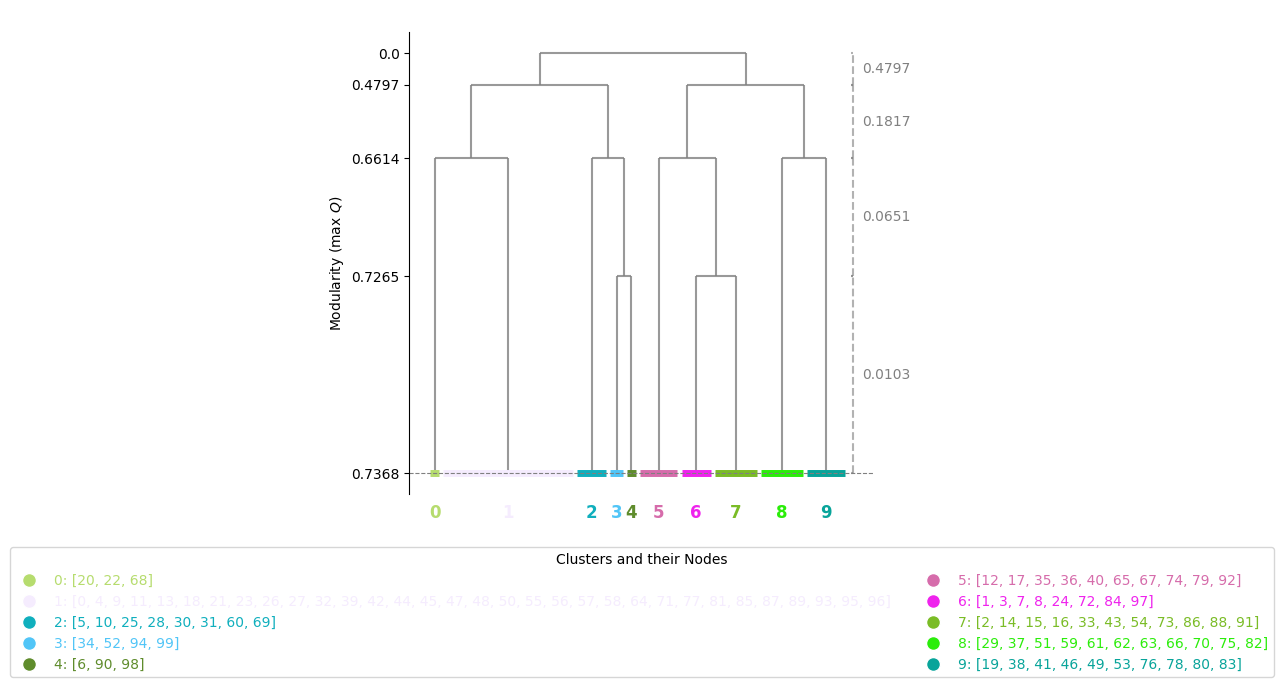

In [42]:
dendro_gur = Dendrogram(G, communities=commms, division_modularities=div_mods, division_tree=div_tree)
dendro_gur.draw(display_leafs=False, yaxis_abs_log=True, figsize=(6, 6))

In [43]:
comms

[[15, 24, 35, 41, 69, 74, 85],
 [87],
 [20, 75, 82, 84, 88],
 [1, 3, 8, 27, 31, 49, 52, 54, 71, 78, 92, 93, 96],
 [2, 11, 18, 29, 30, 42, 60, 63, 64, 80, 95],
 [5, 9, 23, 33, 37, 43, 46, 48, 57, 61, 73, 77, 86, 94, 99],
 [0,
  6,
  14,
  16,
  17,
  21,
  22,
  25,
  26,
  28,
  34,
  47,
  51,
  53,
  62,
  66,
  67,
  79,
  81,
  83,
  90],
 [10, 76, 98],
 [7, 50, 56, 97],
 [19, 40, 91],
 [12, 13, 32, 36, 38, 39, 45, 55, 58, 70, 72],
 [4, 44, 59, 65, 68, 89]]

In [16]:
res = it_searcher.run_with_sampleset_info(num_runs=num_runs, save_results=False)

  0%|          | 0/20 [00:00<?, ?it/s]


AttributeError: 'dict' object has no attribute 'probabilities'

Let's clear caches for safety

In [10]:
# from minorminer.busclique import busgraph_cache


# busgraph_cache.clear_all_caches()

In [14]:
%time emb = find_clique_embedding(bqm_graph, target_graph=sampler.to_networkx_graph())

CPU times: total: 1min 44s
Wall time: 2min 19s


In [20]:
len(emb.keys())

100

In [21]:
%time emb = find_clique_embedding(bqm_graph, target_graph=sampler.to_networkx_graph())

CPU times: total: 0 ns
Wall time: 69 ms


In [22]:
from dwave.system.composites import FixedEmbeddingComposite


sample_cl = FixedEmbeddingComposite(sampler, embedding=emb).sample(bqm, num_reads=100)

res_cl = sample_cl.first.sample

c0_cl = sorted([int(k[1:]) for k, v in res_cl.items() if v == 0])
c1_cl = sorted([int(k[1:]) for k, v in res_cl.items() if v == 1])

print("c0_cl len:", len(c0_cl))
print("c1_cl len:", len(c1_cl))

print("Sample modularity from FixedEmbeddingComposite:", nx.community.modularity(G, [c0_cl, c1_cl]))

c0_cl len: 53
c1_cl len: 47
Sample modularity from FixedEmbeddingComposite: 0.4785225997347209


Sampling works.

#### Now let's take a subcommunity from that graph, subcommunity of 99 nodes:

In [23]:
network = Network(graph=G, community=[*range(99)])
problem = CommunityDetectionProblem(network_data=network, communities=2, one_hot_encoding=False)

qubo = Converter.create_qubo(problem, [])
qubo_terms, offset = convert_qubo_keys(qubo)
bqm = BinaryQuadraticModel.from_qubo(qubo_terms, offset=offset)

bqm_graph = bqm.to_networkx_graph()

C:\Users\basia\AppData\Local\Temp\ipykernel_59808\176734912.py:8: DeprecationWarning: BinaryQuadraticModel.to_networkx_graph() is deprecated since dimod 0.10.0 and will be removed in 0.12.0. Use dimod.to_networkx_graph() instead.
  bqm_graph = bqm.to_networkx_graph()


In [24]:
%time emb_2 = find_clique_embedding(bqm_graph, target_graph=sampler.to_networkx_graph())

CPU times: total: 46.9 ms
Wall time: 80.5 ms


In [25]:
len(emb_2.keys())

99

As we can see from the time measured, the cached embedding was used to find embedding for these 99 nodes.

Now let's see the cache'ing behaviour of the cache'ing for a smaller graph (different graph, not subcommunity):

In [30]:
G_90 = Graphs[8]

network = Network(graph=G_90)
problem = CommunityDetectionProblem(network_data=network, communities=2, one_hot_encoding=False)

qubo = Converter.create_qubo(problem, [])
qubo_terms, offset = convert_qubo_keys(qubo)
bqm = BinaryQuadraticModel.from_qubo(qubo_terms, offset=offset)
bqm_graph = bqm.to_networkx_graph()

C:\Users\basia\AppData\Local\Temp\ipykernel_59808\3945948250.py:9: DeprecationWarning: BinaryQuadraticModel.to_networkx_graph() is deprecated since dimod 0.10.0 and will be removed in 0.12.0. Use dimod.to_networkx_graph() instead.
  bqm_graph = bqm.to_networkx_graph()


In [31]:
%time emb_3 = find_clique_embedding(bqm_graph, target_graph=sampler.to_networkx_graph())

CPU times: total: 31.2 ms
Wall time: 73.3 ms


It used cached embedding as well.

Ok, so now let's take a bigger graph, new one, of 150 nodes.

In [32]:
G_150 = nx.powerlaw_cluster_graph(n=150, m=2, p=0.2)
network = Network(graph=G_150)
problem = CommunityDetectionProblem(network_data=network, communities=2, one_hot_encoding=False)

qubo = Converter.create_qubo(problem, [])
qubo_terms, offset = convert_qubo_keys(qubo)
bqm = BinaryQuadraticModel.from_qubo(qubo_terms, offset=offset)
bqm_graph = bqm.to_networkx_graph()

C:\Users\basia\AppData\Local\Temp\ipykernel_59808\1647688498.py:8: DeprecationWarning: BinaryQuadraticModel.to_networkx_graph() is deprecated since dimod 0.10.0 and will be removed in 0.12.0. Use dimod.to_networkx_graph() instead.
  bqm_graph = bqm.to_networkx_graph()


In [33]:
%time emb_150 = find_clique_embedding(bqm_graph, target_graph=sampler.to_networkx_graph())

CPU times: total: 46.9 ms
Wall time: 75.1 ms


It used cache as well.

In [35]:
len(emb_150.keys())

150

That's because find_clique_embedding uses busgraph_cache(target_graph).find_clique_embedding(nn) inside: \
https://docs.ocean.dwavesys.com/en/stable/docs_minorminer/source/reference/generated/minorminer.busclique.busgraph_cache.find_clique_embedding.html#minorminer.busclique.busgraph_cache.find_clique_embedding

In [53]:
emb_cached_150 = busgraph_cache(sampler_graph).find_clique_embedding(['x'+str(i) for i in range(150)])

In [56]:
emb_cached_150 == emb_150

True

So the embeddings are cached up to the size of:

In [36]:
busgraph_cache(sampler_graph).largest_clique().keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168])

In [37]:
len(busgraph_cache(sampler_graph).largest_clique().keys())

169

#### Trying to extract info from the caching files

In [72]:
import os
from minorminer.busclique import busgraph_cache


# From docs - this is where they are stored
cache_dir = busgraph_cache.cache_rootdir()
print(f"Cache directory: {cache_dir}")

cache_files = os.listdir(cache_dir)
print(f"Cache files in {busgraph_cache.cache_rootdir()}:", cache_files)

# Inside the "clique" dir
cache_dir += "\\clique"
cache_files = os.listdir(cache_dir)
print(f"Cache files in {cache_dir}:", cache_files)

Cache directory: C:\Users\basia\AppData\Local\dwave\busclique_7
Cache files in C:\Users\basia\AppData\Local\dwave\busclique_7: ['clique']
Cache files in C:\Users\basia\AppData\Local\dwave\busclique_7\clique: ['.lock', '.lru', 'pegasus_599a4b13e9291929']


In [84]:
import pickle


lru_file_path = os.path.join(cache_dir, '.lock')
print(lru_file_path)


with open(lru_file_path, 'rb') as file:
    cache_content = pickle.load(file)


print(type(cache_content))
print("Cache content:", cache_content)

C:\Users\basia\AppData\Local\dwave\busclique_7\clique\.lock


EOFError: Ran out of input

Oops...

In [85]:
lru_file_path = os.path.join(cache_dir, '.lru')
print(lru_file_path)


with open(lru_file_path, 'rb') as file:
    cache_content = pickle.load(file)

print(type(cache_content))
print("Cache content:", cache_content)

C:\Users\basia\AppData\Local\dwave\busclique_7\clique\.lru
<class 'list'>
Cache content: ['pegasus_599a4b13e9291929']


In [86]:
%%capture cap


lru_file_path = os.path.join(cache_dir, 'pegasus_599a4b13e9291929')
print(lru_file_path)


with open(lru_file_path, 'rb') as file:
    cache_content = pickle.load(file)

print("Cache content:", cache_content)

with open('cache_file.txt', 'w') as file:
    file.write(cap.stdout)

print(type(cache_content))